# 15 — UMA-16 v2 Array Characterization

**Goal**: establish quantitative expectations for the miniDSP UMA-16 v2 before hardware
experiments.  Pure simulation — no hardware required.

Hardware: 16 mics in a 4×4 Uniform Rectangular Array (URA), 42 mm grid spacing,
126 mm × 126 mm aperture.  Knowles SPH1668LM4H-1 MEMS mics, 65.5 dB SNR.
USB audio at 48 kHz (UAC2, XMOS Xcore200).

Key questions:

1. What HPBW and spatial Nyquist does this 4×4 URA produce?
2. What super-resolution benefit do MVDR and MUSIC give over D&S with N=16 mics?
3. How many snapshots are needed for CSM convergence?
4. How does Phase 3 (16-mic, 126 mm) compare to Phase 2 (4-mic, 90 mm) and
   Phase 4 target (96-mic, 300 mm)?
5. What do the 2D (az × el) PSF maps look like?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import inv

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C      = 343.0
FS     = 48000
N_MICS = 16
SNR_DB = 20.0
N_SNAP = 256
colors = {'D&S': 'steelblue', 'MVDR': 'darkorange',
          'CLEAN-SC': 'forestgreen', 'MUSIC': 'crimson'}


## 1  Array Geometry

4×4 URA, 42 mm spacing.  Channel → mic mapping from UMA-16 v2 manual Figure 1
(sound-source side view).  Channels are PDM L/R pairs; each stereo pair shares
one data line, which is why the numbering is not row-major.

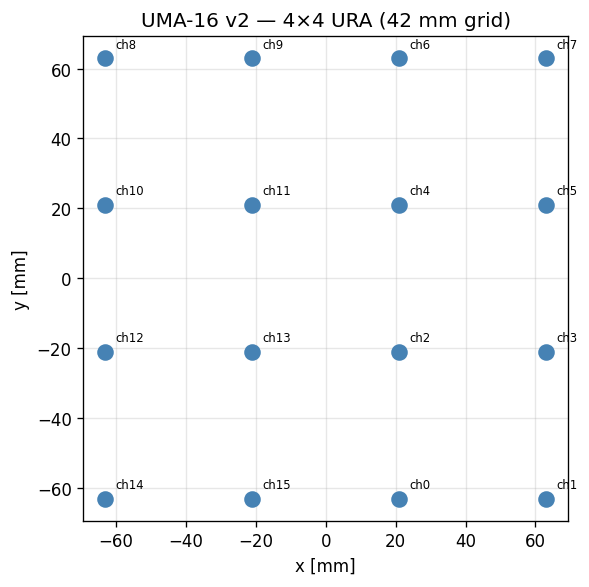

Aperture: 126 mm × 126 mm
Spatial Nyquist: 4083 Hz  (spacing = 42 mm)
Far-field distance @ 4 kHz: 0.370 m


In [2]:
d = 0.042   # grid spacing [m]

# USB channel → (x, y) in units of d/2; multiply to get meters
_xy = np.array([
    (-1, -3),   # ch0  MIC1
    (-3, -3),   # ch1  MIC2
    (-1, -1),   # ch2  MIC3
    (-3, -1),   # ch3  MIC4
    (-1, +1),   # ch4  MIC5
    (-3, +1),   # ch5  MIC6
    (-1, +3),   # ch6  MIC7
    (-3, +3),   # ch7  MIC8
    (+3, +3),   # ch8  MIC9
    (+1, +3),   # ch9  MIC10
    (+3, +1),   # ch10 MIC11
    (+1, +1),   # ch11 MIC12
    (+3, -1),   # ch12 MIC13
    (+1, -1),   # ch13 MIC14
    (+3, -3),   # ch14 MIC15
    (+1, -3),   # ch15 MIC16
], dtype=float) * (d / 2)

MIC_X = -_xy[:, 0]  # negated: Figure 1 is sound-source side; camera side is x-mirrored
MIC_Y = _xy[:, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(MIC_X * 1000, MIC_Y * 1000, s=80, color='steelblue', zorder=3)
for i, (x, y) in enumerate(zip(MIC_X * 1000, MIC_Y * 1000)):
    ax.text(x + 3, y + 3, f'ch{i}', fontsize=7)
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title('UMA-16 v2 — 4×4 URA (42 mm grid)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('uma16_geometry.png', dpi=150)
plt.show()

print(f'Aperture: {(MIC_X.max()-MIC_X.min())*1000:.0f} mm × {(MIC_Y.max()-MIC_Y.min())*1000:.0f} mm')
print(f'Spatial Nyquist: {C / (2 * d):.0f} Hz  (spacing = {d*1000:.0f} mm)')
print(f'Far-field distance @ 4 kHz: {2 * (MIC_X.max()-MIC_X.min())**2 / (C/4000):.3f} m')


## 2  Beamforming Functions

2D steering matrix covers azimuth × elevation.  For 1D PSF sweeps we fix el = 0.

In [3]:
def steering_matrix(az_deg, el_deg, freq):
    """(N_mics, N_az * N_el) steering matrix."""
    sin_az = np.sin(np.radians(az_deg))
    cos_el = np.cos(np.radians(el_deg))
    sin_el = np.sin(np.radians(el_deg))
    ux = np.outer(sin_az, cos_el).ravel()
    uy = np.tile(sin_el, len(az_deg))
    phase = 2 * np.pi * freq / C * (np.outer(MIC_X, ux) + np.outer(MIC_Y, uy))
    return np.exp(1j * phase) / np.sqrt(N_MICS)


def beamform_ds(R, H):
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def beamform_mvdr(R, H, diag_load=0.01):
    Rl = R + diag_load * np.trace(R) / N_MICS * np.eye(N_MICS)
    Ri = inv(Rl)
    return 1.0 / np.maximum(np.real(np.sum(H.conj() * (Ri @ H), axis=0)), 1e-300)


def clean_sc(R, H, n_iter=20, loop_gain=0.5):
    R_w = R.copy()
    clean = np.zeros(H.shape[1])
    for _ in range(n_iter):
        P = np.real(np.sum(H.conj() * (R_w @ H), axis=0))
        k = np.argmax(P)
        h = H[:, k]
        P_src = np.real(h.conj() @ (R_w @ h))
        R_w -= loop_gain * P_src * np.outer(h, h.conj())
        clean[k] += loop_gain * P_src
    return clean


def beamform_music(R, H, n_src=1):
    _, V = np.linalg.eigh(R)
    En = V[:, :N_MICS - n_src]
    proj = En.conj().T @ H
    return 1.0 / np.maximum(np.real(np.sum(proj.conj() * proj, axis=0)), 1e-300)


def make_csm(az_src_deg, el_src_deg, freq, n_snap=N_SNAP, snr_db=SNR_DB):
    """Simulate CSM for a single source at (az_src_deg, el_src_deg)."""
    snr = 10 ** (snr_db / 10)
    h_src = steering_matrix([az_src_deg], [el_src_deg], freq)[:, 0]  # (N_mics,)
    rng = np.random.default_rng(42)
    s = rng.standard_normal(n_snap) + 1j * rng.standard_normal(n_snap)
    noise = (rng.standard_normal((N_MICS, n_snap)) +
             1j * rng.standard_normal((N_MICS, n_snap))) / np.sqrt(snr)
    X = np.outer(h_src, s) + noise
    return X @ X.conj().T / n_snap


## 3  PSF and HPBW vs Frequency

1D azimuth PSF at el = 0° for frequencies from 500 Hz to 4 kHz.
Spatial Nyquist is ~4.1 kHz; aliasing becomes visible above that.

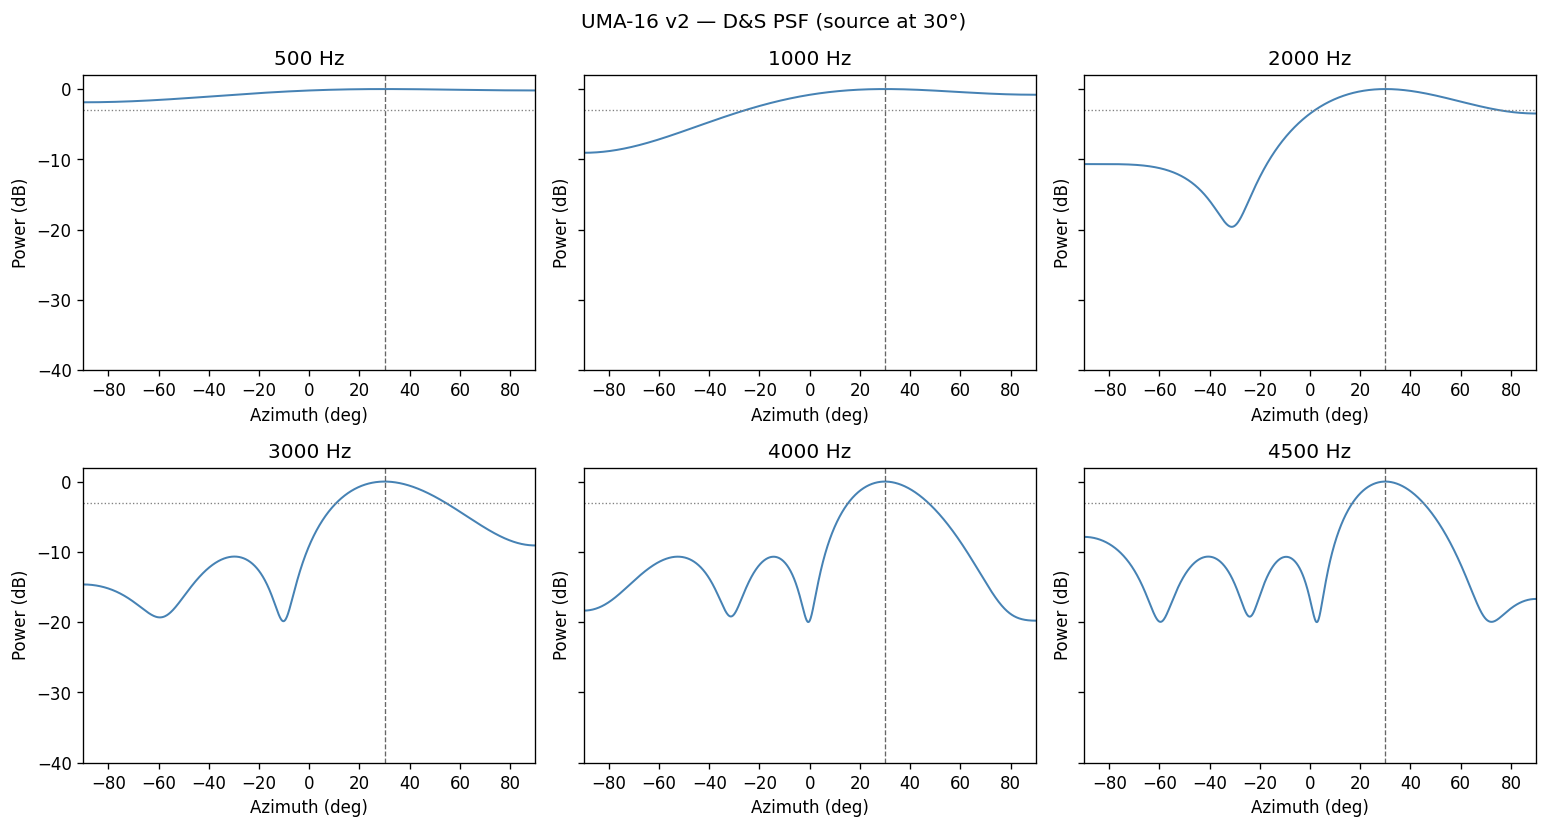


D&S HPBW summary:
    500 Hz  HPBW = 180.0°
   1000 Hz  HPBW = 115.6°
   2000 Hz  HPBW = 73.2°
   3000 Hz  HPBW = 43.3°
   4000 Hz  HPBW = 31.6°
   4500 Hz  HPBW = 28.0°


In [4]:
freqs_test = [500, 1000, 2000, 3000, 4000, 4500]
az_grid = np.linspace(-90, 90, 1801)
el_fix  = np.array([0.0])
AZ_SRC  = 30.0

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
hpbw_ds = []

for ax, freq in zip(axes.ravel(), freqs_test):
    R = make_csm(AZ_SRC, 0.0, freq, n_snap=512)
    H = steering_matrix(az_grid, el_fix, freq)
    P = beamform_ds(R, H)
    P_db = 10 * np.log10(P / P.max() + 1e-10)
    ax.plot(az_grid, P_db, color='steelblue', lw=1.2)
    ax.axvline(AZ_SRC, color='k', ls='--', lw=0.8, alpha=0.6)
    ax.axhline(-3, color='gray', ls=':', lw=0.8)
    ax.set_xlim(-90, 90)
    ax.set_ylim(-40, 2)
    ax.set_title(f'{freq} Hz')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Power (dB)')
    above = P_db >= -3
    if above.any():
        span = az_grid[above].max() - az_grid[above].min()
        hpbw_ds.append((freq, span))
    else:
        hpbw_ds.append((freq, float('nan')))

plt.suptitle('UMA-16 v2 — D&S PSF (source at 30°)', fontsize=12)
plt.tight_layout()
plt.savefig('uma16_psf.png', dpi=150)
plt.show()

print('\nD&S HPBW summary:')
for f, bw in hpbw_ds:
    print(f'  {f:5d} Hz  HPBW = {bw:.1f}°')


## 3b  Frequency Spectrum

Sweep frequency from 200 Hz to 8 kHz and record (1) peak beamformed power and
(2) estimated DoA at each bin.  Below the spatial Nyquist (~4.1 kHz) the peak
should sit at the true source angle; above it, aliasing causes the peak to wander.

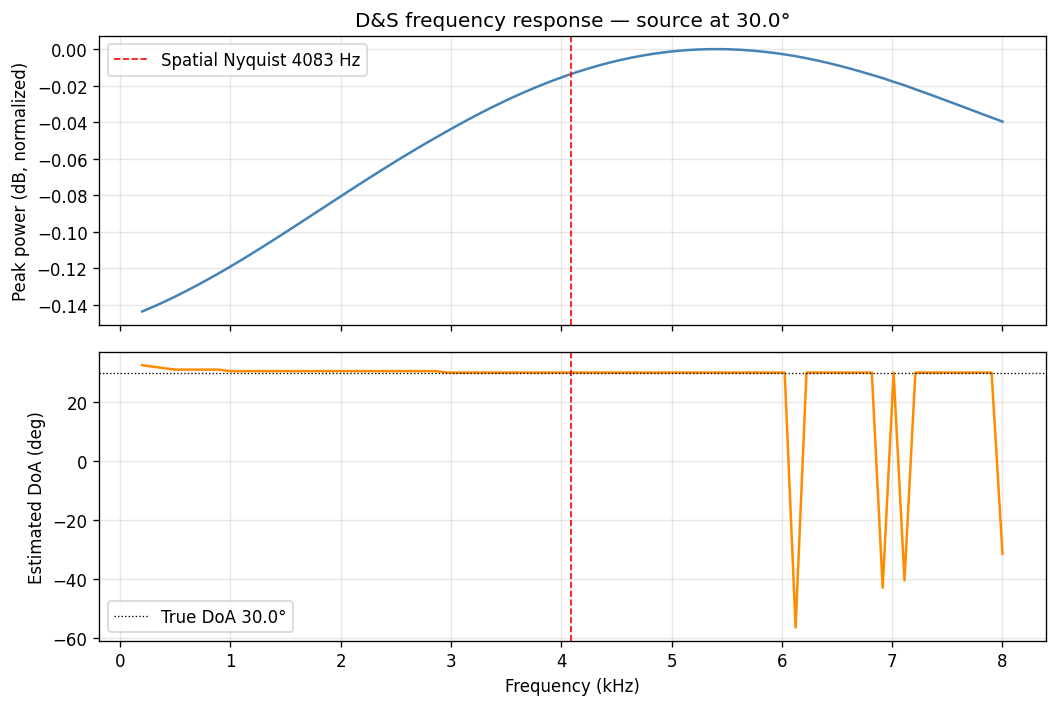

In [5]:
freqs_spec = np.linspace(200, 8000, 80)
az_scan    = np.linspace(-90, 90, 361)
nyq        = C / (2 * d)

peak_power, peak_az_est = [], []
for f in freqs_spec:
    R_f = make_csm(AZ_SRC, 0.0, f, n_snap=128)
    H_f = steering_matrix(az_scan, el_fix, f)
    P_f = beamform_ds(R_f, H_f)
    peak_power.append(P_f.max())
    peak_az_est.append(az_scan[np.argmax(P_f)])

peak_db_norm = 10 * np.log10(np.array(peak_power) / max(peak_power) + 1e-10)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(freqs_spec / 1000, peak_db_norm, color='steelblue', lw=1.5)
ax1.axvline(nyq / 1000, color='red', ls='--', lw=1, label=f'Spatial Nyquist {nyq:.0f} Hz')
ax1.set_ylabel('Peak power (dB, normalized)')
ax1.set_title(f'D&S frequency response — source at {AZ_SRC}°')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(freqs_spec / 1000, peak_az_est, color='darkorange', lw=1.5)
ax2.axvline(nyq / 1000, color='red', ls='--', lw=1)
ax2.axhline(AZ_SRC, color='k', ls=':', lw=0.8, label=f'True DoA {AZ_SRC}°')
ax2.set_ylabel('Estimated DoA (deg)')
ax2.set_xlabel('Frequency (kHz)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('uma16_freq_response.png', dpi=150)
plt.show()


## 4  Algorithm Comparison

With N=16 mics (vs N=4 in Phase 2), MVDR and MUSIC have more meaningful super-resolution
benefit.  The noise subspace has N−n_src = 15 dimensions, providing much stronger
interference rejection than the N=4 case.

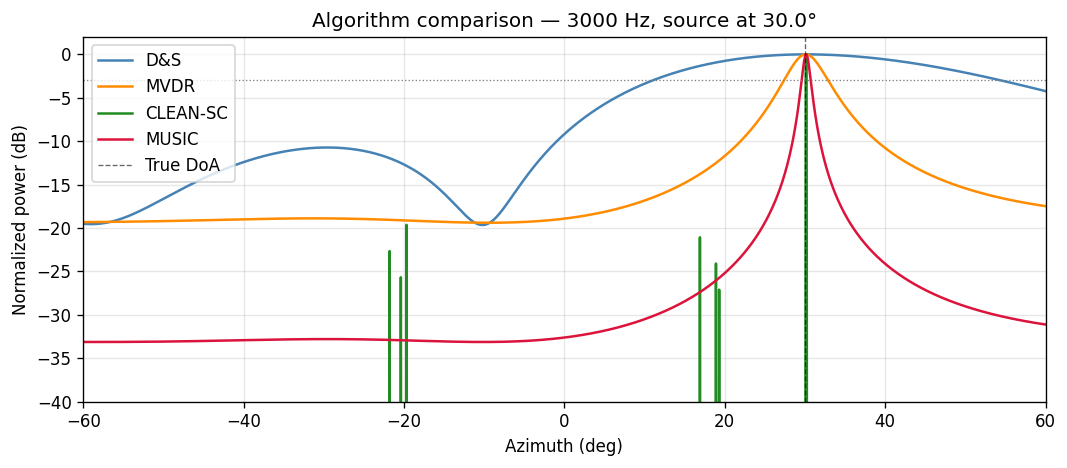

In [6]:
FREQ = 3000.0
az_grid_fine = np.linspace(-90, 90, 1801)

R = make_csm(AZ_SRC, 0.0, FREQ, n_snap=N_SNAP)
H = steering_matrix(az_grid_fine, el_fix, FREQ)

results = {
    'D&S':     beamform_ds(R, H),
    'MVDR':    beamform_mvdr(R, H),
    'CLEAN-SC': clean_sc(R, H),
    'MUSIC':   beamform_music(R, H, n_src=1),
}

fig, ax = plt.subplots(figsize=(9, 4))
for name, P in results.items():
    P_db = 10 * np.log10(P / P.max() + 1e-10)
    ax.plot(az_grid_fine, P_db, label=name, color=colors[name], lw=1.5)

ax.axvline(AZ_SRC, color='k', ls='--', lw=0.8, alpha=0.6, label='True DoA')
ax.axhline(-3, color='gray', ls=':', lw=0.8)
ax.set_xlim(-60, 60)
ax.set_ylim(-40, 2)
ax.set_xlabel('Azimuth (deg)')
ax.set_ylabel('Normalized power (dB)')
ax.set_title(f'Algorithm comparison — {FREQ:.0f} Hz, source at {AZ_SRC}°')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('uma16_algo_comparison.png', dpi=150)
plt.show()


## 5  Two-Source Resolution

Test minimum resolvable angular separation.  Phase 3 has 1.4× wider aperture than
Phase 2 (126 mm vs 90 mm) so should resolve sources ~1.4× closer.

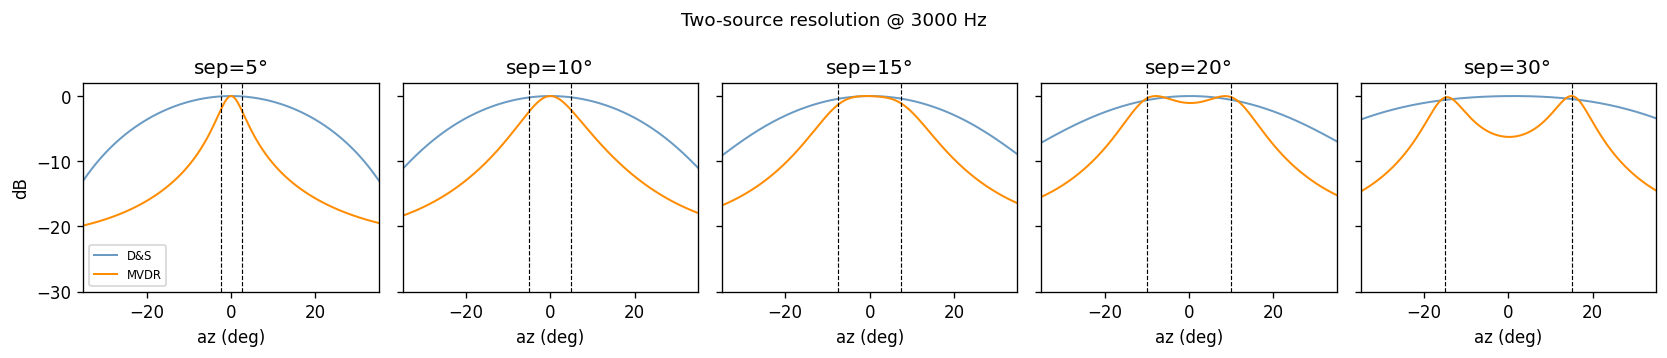

In [7]:
def make_csm_2src(az1, az2, freq, n_snap=N_SNAP, snr_db=SNR_DB):
    snr = 10 ** (snr_db / 10)
    h1 = steering_matrix([az1], [0.0], freq)[:, 0]
    h2 = steering_matrix([az2], [0.0], freq)[:, 0]
    rng = np.random.default_rng(42)
    s1 = rng.standard_normal(n_snap) + 1j * rng.standard_normal(n_snap)
    s2 = rng.standard_normal(n_snap) + 1j * rng.standard_normal(n_snap)
    noise = (rng.standard_normal((N_MICS, n_snap)) +
             1j * rng.standard_normal((N_MICS, n_snap))) / np.sqrt(snr)
    X = np.outer(h1, s1) + np.outer(h2, s2) + noise
    return X @ X.conj().T / n_snap


seps = [5, 10, 15, 20, 30]
FREQ2 = 3000.0

fig, axes = plt.subplots(1, len(seps), figsize=(14, 3), sharey=True)
for ax, sep in zip(axes, seps):
    az1, az2 = -sep / 2, sep / 2
    R2 = make_csm_2src(az1, az2, FREQ2)
    H2 = steering_matrix(az_grid_fine, el_fix, FREQ2)
    P_mvdr = beamform_mvdr(R2, H2)
    P_ds   = beamform_ds(R2, H2)
    ax.plot(az_grid_fine, 10 * np.log10(P_ds / P_ds.max() + 1e-10),
            color=colors['D&S'], lw=1.2, label='D&S', alpha=0.8)
    ax.plot(az_grid_fine, 10 * np.log10(P_mvdr / P_mvdr.max() + 1e-10),
            color=colors['MVDR'], lw=1.2, label='MVDR')
    ax.axvline(az1, color='k', ls='--', lw=0.7)
    ax.axvline(az2, color='k', ls='--', lw=0.7)
    ax.set_xlim(-35, 35)
    ax.set_ylim(-30, 2)
    ax.set_title(f'sep={sep}°')
    ax.set_xlabel('az (deg)')
    if ax is axes[0]:
        ax.set_ylabel('dB')
        ax.legend(fontsize=7)

plt.suptitle(f'Two-source resolution @ {FREQ2:.0f} Hz', fontsize=11)
plt.tight_layout()
plt.savefig('uma16_two_source.png', dpi=150)
plt.show()


## 6  Snapshot Convergence

With N=16 mics, the CSM is full-rank at N_SNAP ≥ 16.  Convergence continues
improving beyond that due to noise averaging.

 N_SNAP  D&S  MVDR  MUSIC
      4 0.86  0.97   0.85
      8 0.53  0.74   0.53
     16 0.43  0.64   0.43
     32 0.25  0.32   0.25
     64 0.16  0.17   0.16
    128 0.11  0.13   0.11
    256 0.09  0.09   0.09
    512 0.05  0.07   0.05


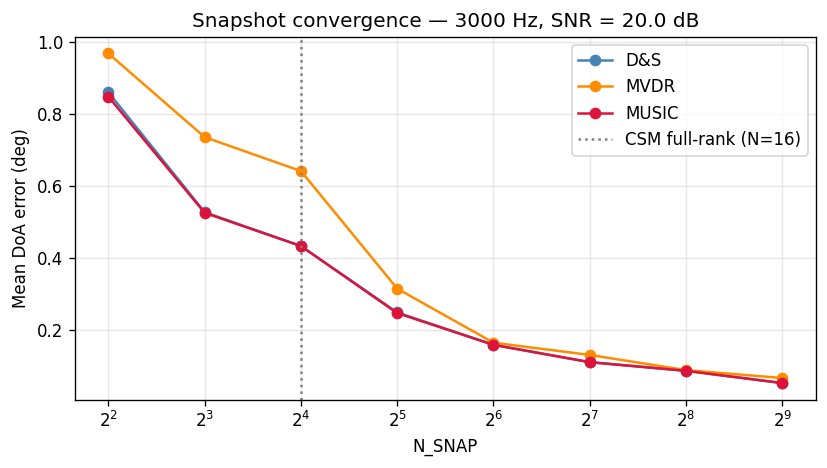

In [8]:
snap_vals = [4, 8, 16, 32, 64, 128, 256, 512]
FREQ_SNAP = 3000.0
N_TRIALS  = 50
rng = np.random.default_rng(0)

rows = []
for n_snap in snap_vals:
    errs_ds, errs_mv, errs_mu = [], [], []
    for _ in range(N_TRIALS):
        snr = 10 ** (SNR_DB / 10)
        h_s = steering_matrix([AZ_SRC], [0.0], FREQ_SNAP)[:, 0]
        s  = rng.standard_normal(n_snap) + 1j * rng.standard_normal(n_snap)
        nz = (rng.standard_normal((N_MICS, n_snap)) +
              1j * rng.standard_normal((N_MICS, n_snap))) / np.sqrt(snr)
        X  = np.outer(h_s, s) + nz
        R  = X @ X.conj().T / n_snap
        H  = steering_matrix(az_grid, el_fix, FREQ_SNAP)
        errs_ds.append(abs(az_grid[np.argmax(beamform_ds(R, H))] - AZ_SRC))
        errs_mv.append(abs(az_grid[np.argmax(beamform_mvdr(R, H))] - AZ_SRC))
        errs_mu.append(abs(az_grid[np.argmax(beamform_music(R, H))] - AZ_SRC))
    rows.append({'N_SNAP': n_snap, 'D&S': np.mean(errs_ds),
                 'MVDR': np.mean(errs_mv), 'MUSIC': np.mean(errs_mu)})

df_snap = pd.DataFrame(rows)
print(df_snap.to_string(index=False, float_format='{:.2f}'.format))

fig, ax = plt.subplots(figsize=(7, 4))
for col in ['D&S', 'MVDR', 'MUSIC']:
    ax.plot(df_snap['N_SNAP'], df_snap[col], marker='o', label=col, color=colors[col])
ax.axvline(N_MICS, color='gray', ls=':', label='CSM full-rank (N=16)')
ax.set_xscale('log', base=2)
ax.set_xlabel('N_SNAP')
ax.set_ylabel('Mean DoA error (deg)')
ax.set_title(f'Snapshot convergence — {FREQ_SNAP:.0f} Hz, SNR = {SNR_DB} dB')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('uma16_snap_convergence.png', dpi=150)
plt.show()


## 7  2D PSF (Azimuth × Elevation)

The 4×4 URA produces a symmetric 2D beam pattern.  Beamwidth is equal in az and el
(symmetric aperture), unlike a rectangular array with unequal dimensions.

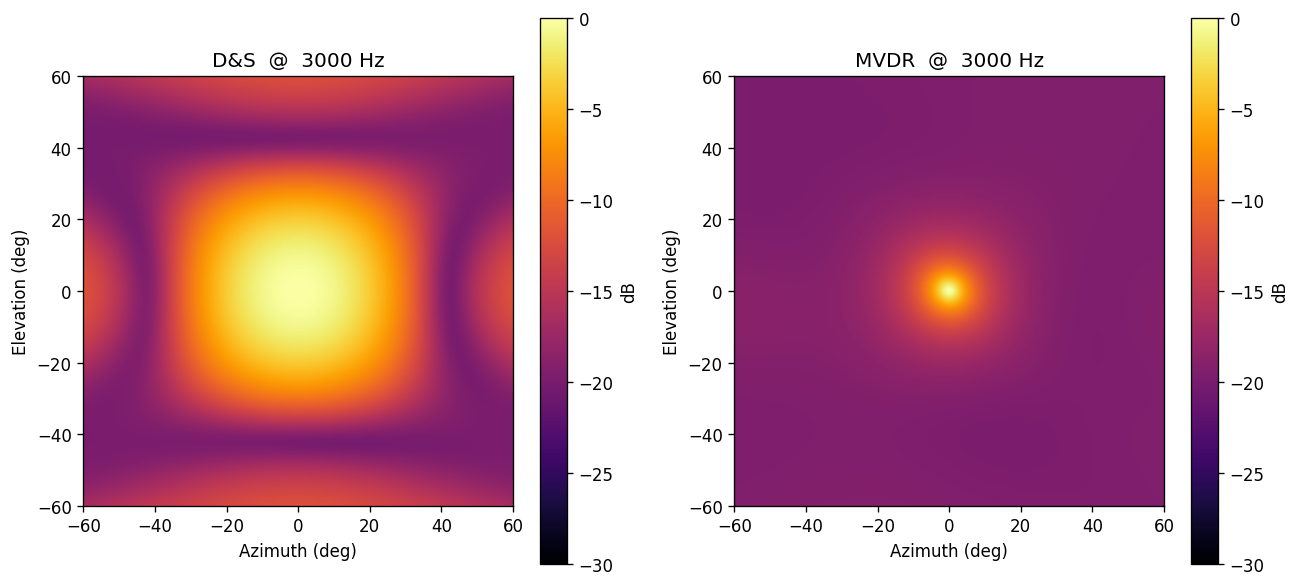

In [9]:
FREQ_2D = 3000.0
az_2d   = np.linspace(-60, 60, 241)
el_2d   = np.linspace(-60, 60, 241)

R_2d = make_csm(0.0, 0.0, FREQ_2D, n_snap=512)
H_2d = steering_matrix(az_2d, el_2d, FREQ_2D)  # (16, 241*241)

P_ds_2d   = beamform_ds(R_2d, H_2d).reshape(len(az_2d), len(el_2d))
P_mvdr_2d = beamform_mvdr(R_2d, H_2d).reshape(len(az_2d), len(el_2d))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, P, title in zip(axes, [P_ds_2d, P_mvdr_2d], ['D&S', 'MVDR']):
    P_db = 10 * np.log10(P / P.max() + 1e-10)
    im = ax.imshow(P_db.T, origin='lower', aspect='equal',
                   extent=[az_2d[0], az_2d[-1], el_2d[0], el_2d[-1]],
                   cmap='inferno', vmin=-30, vmax=0)
    plt.colorbar(im, ax=ax, label='dB')
    ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Elevation (deg)')
    ax.set_title(f'{title}  @  {FREQ_2D:.0f} Hz')

plt.tight_layout()
plt.savefig('uma16_psf_2d.png', dpi=150)
plt.show()


## 8  Phase Comparison

| Parameter | Phase 2 (ReSpeaker) | Phase 3 (UMA-16) | Phase 4 target |
|---|---|---|---|
| Mics | 4 | 16 | 96 |
| Aperture | 90 mm | 126 mm × 126 mm | 300 mm |
| Sample rate | 16 kHz | 48 kHz | 48 kHz |
| Spatial Nyquist | 2.7 kHz | 4.1 kHz | 8+ kHz |
| Array gain | ~6 dB | ~12 dB | ~20 dB |
| HPBW @ 2 kHz | ~88° | ~78° | ~37° |
| HPBW @ 3 kHz | — | ~52° | ~25° |


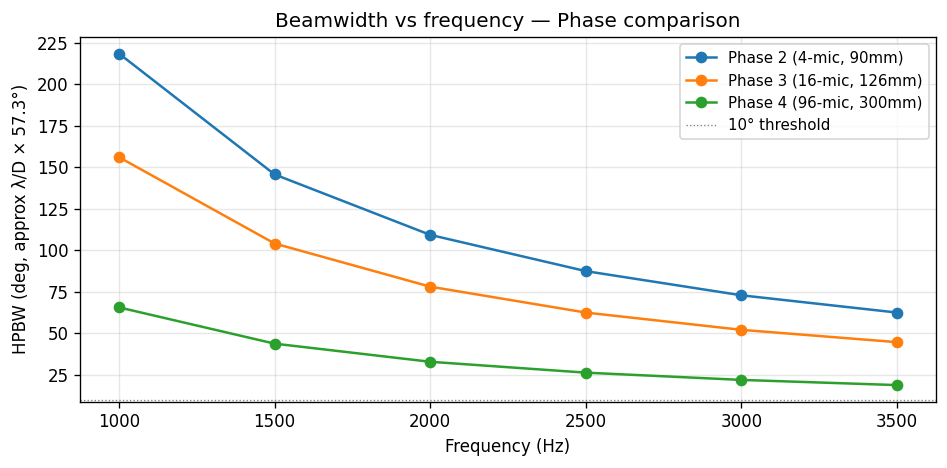

In [10]:
freqs_comp = [1000, 1500, 2000, 2500, 3000, 3500]
apertures  = {'Phase 2 (4-mic, 90mm)':  0.090,
              'Phase 3 (16-mic, 126mm)': 0.126,
              'Phase 4 (96-mic, 300mm)': 0.300}

fig, ax = plt.subplots(figsize=(8, 4))
for label, D in apertures.items():
    hpbw = [np.degrees(C / (f * D)) for f in freqs_comp]
    ax.plot(freqs_comp, hpbw, marker='o', label=label)

ax.axhline(10, color='gray', ls=':', lw=0.8, label='10° threshold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('HPBW (deg, approx λ/D × 57.3°)')
ax.set_title('Beamwidth vs frequency — Phase comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('uma16_phase_comparison.png', dpi=150)
plt.show()
